# Motor Insurance Pricing — Claim Frequency Modeling

**Goal of this notebook:** To predict the expected number of claims (`ClaimNb`) per policyholder, using a Poisson GLM with `Exposure` as an offset using the cleaned data from the previous notebook (`02_data_cleaning.ipynb`).

**Steps:**
1. Explore the target variable and confirm if it's suited to a Poisson model.
2. Prepare features such as encoding and train/test split.
3. Fit a baseline Poisson Generalized Linear Model (GLM) with Exposure as the offset.
4. Check model assumptions such as overdispersion
5. Compare models (e.g. Poisson vs Negative Binomial) via AIC / log-likelihood
6. Summary of findings

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

DATA_DIR = "../data/processed"

freq = pd.read_csv(f"{DATA_DIR}/freMTPL2freq_clean.csv")
print(freq.shape)
freq.head()

(678013, 14)


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,VehAge_capped,DrivAge_capped
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0,55
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0,55
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,2,52
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0,46
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0,46


## 1. Target variable exploration

Firstly, I will check whether `ClaimNb` actually looks like something a Poisson process could produce. Specifically, I want to look at whether its mean and variance are roughly equal which is a core Poisson assumption.

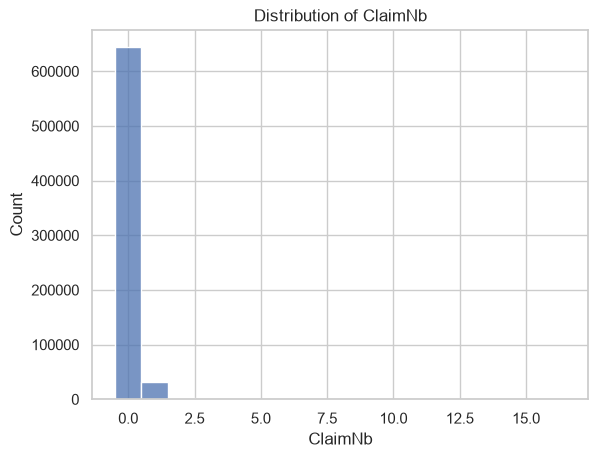

Mean:     0.0532
Variance: 0.0577
Variance / Mean ratio: 1.08


In [5]:
sns.histplot(freq["ClaimNb"], discrete=True)
plt.title("Distribution of ClaimNb")
plt.show()

mean_claims = freq["ClaimNb"].mean()
var_claims = freq["ClaimNb"].var()
print(f"Mean:     {mean_claims:.4f}")
print(f"Variance: {var_claims:.4f}")
print(f"Variance / Mean ratio: {var_claims / mean_claims:.2f}")

##### Findings:

The Variance / Mean ratio comes out to 1.08 which is only slightly above 1. This means that there is no strong sign of overdispersion at this stage and this means that there is no evidence against the use of a Poisson GLM, so it should be acceptable to use initally. However its important to consider the effect of Exposure. This check does not account for the Exposure values which ranges from a tiny fraction up to 1.0. This means that if there are two policies identical in every risk feature except that one has an Exposure value of 0.5 while the other has a value of 1.0, we would expect to see roughly half as many claims from the first policy compared to the second, simply because there is less time for the policy to act. Similarly, this raw check doesn't account for the risk features themselves (Driver Age, BonusMalus, etc.). For this reason, the more thorough examination in Section 4 takes both exposure and the fitted model's residuals into account, making it more reliable than the preliminary analysis done here.

## 2. Feature preparation

### 2a. Choose features and encode categoricals

I will group rare categories that were identified in the 01_data_exploration notebook into "Other" before encoding, so the model isn't trying to learn from categories with only a handful of policies.

In [9]:
freq["VehBrand"].value_counts()


VehBrand
B12      166024
B1       162736
B2       159861
B3        53395
B5        34753
B6        28548
B4        25179
B10       17707
B11       13585
B13       12178
Other      4047
Name: count, dtype: int64

In [8]:
freq["Region"].value_counts()

Region
Centre                         160601
Rhone-Alpes                     84752
Provence-Alpes-Cotes-D'Azur     79315
Ile-de-France                   69791
Other                           59085
Bretagne                        42122
Nord-Pas-de-Calais              40275
Pays-de-la-Loire                38751
Languedoc-Roussillon            35805
Aquitaine                       31329
Poitou-Charentes                19046
Midi-Pyrenees                   17141
Name: count, dtype: int64

In [6]:
MIN_CATEGORY_COUNT = 12000 # I picked this value to ensure that each category has enough data for modelling the data. You can adjust this threshold based on your specific needs and the distribution of your data.

for col in ["VehBrand", "Region"]:
    counts = freq[col].value_counts()
    rare = counts[counts < MIN_CATEGORY_COUNT].index
    freq[col] = freq[col].where(~freq[col].isin(rare), "Other")
    print(f"{col}: grouped {len(rare)} rare categories into 'Other'")

VehBrand: grouped 1 rare categories into 'Other'
Region: grouped 10 rare categories into 'Other'


In [7]:
feature_cols = ["VehPower", "VehAge_capped", "DrivAge_capped", "BonusMalus", "VehBrand", "VehGas", "Area", "Region", "Density"]

model_df = freq[feature_cols + ["ClaimNb", "Exposure"]].copy()

# log-transform Density (heavily right-skewed, per EDA findings)
model_df["log_Density"] = np.log(model_df["Density"])
model_df = model_df.drop(columns="Density")

model_df.head()

,VehPower,VehAge_capped,DrivAge_capped,BonusMalus,VehBrand,VehGas,Area,Region,ClaimNb,Exposure,log_Density
0,5,0,55,50,B12,Regular,D,Rhone-Alpes,1,0.10,7.104144
1,5,0,55,50,B12,Regular,D,Rhone-Alpes,1,0.77,7.104144
2,6,2,52,50,B12,Diesel,B,Other,1,0.75,3.988984
3,7,0,46,50,B12,Diesel,B,Aquitaine,1,0.09,4.330733
4,7,0,46,50,B12,Diesel,B,Aquitaine,1,0.84,4.330733


### 2b. Train / test split

In [10]:
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (542410, 11)
Test shape: (135603, 11)


## 3. Baseline Poisson GLM

`Exposure` is entered as an offset (via `log(Exposure)`). This is to tell the model to adjust the expected count for how long each policy was actually observed, rather than treating it as just another predictor.

In [ ]:
formula = ( "ClaimNb ~ VehPower + VehAge_capped + DrivAge_capped + BonusMalus " "+ C(VehBrand) + C(VehGas) + C(Area) + C(Region) + log_Density")

poisson_model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Poisson(),
    offset=np.log(train_df["Exposure"])
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542377
Model Family:                 Poisson   Df Model:                           32
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1455e+05
Date:                Fri, 07 Aug 2026   Deviance:                   1.7371e+05
Time:                        22:49:12   Pearson chi2:                 1.42e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01067
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

##### Findings:

- In the Vehicle Brands category, most brands are not statistically significant when compared to the reference brand with the exception of B5 and the 'Other' groups which have more claims and fewer claims respectively
- BonusMalus and log_Density both show small but highly significant positive effects, consistent with intuition. 
- The Driver Age category is particularly interesting as it shows a positive coefficient. This is the opposite of what I had found previously in the bivariate analysis, that younger drivers are more risky as they have the highest frequency. This is likely due to how this model corrects for BonusMalus with which Driver Age is correlated. This is worth investigating further as its an example of how univariate patterns and multivariate coefficients can tell different stories, precisely because multivariate models isolate the marginal effect of one variable after removing what's already explained by correlated variables.
- Vehicle Gas, Vehicle Power and Vehicle age all show small but statistically significant effects which match earlier intuition. 
- What is interesting is that Area shows no significant effects once log_Density is included, however this is explained by the fact that Area is derived from Density (see EDA) and the two portray the same information. This further proves the redundancy mentioned prior. 
- Several regions such as Centre, Rhone-Alpes, Bretagne or Ile-de-France show significant positive effects relative to the baseline region. 
- Interestingly, Centre's positive coefficient here contrasts with its comparatively low raw claim frequency found in the EDA bivariate analysis likely because the model coefficient reflects Centre's effect after controlling for other risk factors, whereas the raw frequency did not account for compositional differences such as driver age or vehicle type between regions.

## 4. Checking model assumptions — overdispersion

A formal check to accompany the mean/variance ratio from Section 1: compare the model's Chi-square statistic to its degrees of freedom. A ratio well above 1 signals overdispersion, meaning a Negative Binomial model likely fits better than Poisson.

In [13]:
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid
dispersion_ratio = pearson_chi2 / df_resid

print(f"Pearson chi2:      {pearson_chi2:.2f}")
print(f"Degrees of freedom: {df_resid:.0f}")
print(f"Dispersion ratio:   {dispersion_ratio:.3f}")

Pearson chi2:      1424873.54
Degrees of freedom: 542377
Dispersion ratio:   2.627


##### Findings:

As we can see, a ratio value of around 2.6 provides strong evidence that overdispersion is occuring. This proves that further examination than from Section 1 was indeed necessary as this directly contradicts the more optimisic result obtained above. This motivates fitting a Negative Binomial model in Section 5, and also means the p-values reported in Section 3 may be overstated (too confident), since Poisson standard errors assume no overdispersion.

## 5. Comparison model — Negative Binomial

We use the Negative Binomial distribution instead of the Poisson distribution when the count data exhibits overdispersion. This means the variance of the data is significantly larger than its mean. 

In [14]:
start_params = np.append(poisson_model.params.values, 0.1)

nb_model = smf.negativebinomial(
    formula=formula,
    data=train_df,
    offset=np.log(train_df["Exposure"])
).fit(start_params=start_params, method="bfgs", maxiter=200, disp=True)

print(nb_model.summary())
print("Estimated alpha:", nb_model.params["alpha"])

Optimization terminated successfully.
         Current function value: 0.210538
         Iterations: 61
         Function evaluations: 64
         Gradient evaluations: 64
                     NegativeBinomial Regression Results                      
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:               NegativeBinomial   Df Residuals:                   542377
Method:                           MLE   Df Model:                           32
Date:                Fri, 07 Aug 2026   Pseudo R-squ.:                 0.02316
Time:                        22:50:18   Log-Likelihood:            -1.1420e+05
converged:                       True   LL-Null:                   -1.1691e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

##### Findings:

- The Negative Binomial model converged successfully with an estimated alpha of 0.982 (p<0.001), confirming meaningful overdispersion. Alpha refers to the dispersion parameter and is essentially a measure of how much the variance of the data exceeds the mean. This is to fix the assumption in Poisson models where the variance must equal the mean. 
- Critically, most Region coefficients that were statistically significant under the Poisson model (e.g. Centre, Ile-de-France, Rhone-Alpes) are no longer significant once the model properly accounts for overdispersion. This directly confirmes the concern raised in Section 4 that Poisson's standard errors were likely overstated. 
- Core risk factors (BonusMalus, Driver Age, Vehicle Age, Vehicle Power, log_Density, Vehicle Gas) remain significant in both models, suggesting these effects are robust rather than artifacts of an overconfident Poisson fit.

## 6. Model comparison

Compare AIC and log-likelihood on the training fit, then check deviance on the held-out test set. AIC and log-likelihood alone can favour overly complex models, so out-of-sample performance matters aswell.

In [15]:
comparison = pd.DataFrame({
    "model": ["Poisson", "Negative Binomial"],
    "AIC": [poisson_model.aic, nb_model.aic],
    "log_likelihood": [poisson_model.llf, nb_model.llf]
})
comparison

,model,AIC,log_likelihood
0,Poisson,229170.916155,-114552.458078
1,Negative Binomial,228463.851938,-114197.925969


In [18]:
# Out-of-sample check: deviance on the test set
estimated_alpha = nb_model.params["alpha"]

test_offset = np.log(test_df["Exposure"])

poisson_pred = poisson_model.predict(test_df, offset=test_offset)
nb_pred = nb_model.predict(test_df, offset=test_offset)

poisson_deviance = sm.families.Poisson().deviance(test_df["ClaimNb"], poisson_pred)
nb_deviance = sm.families.NegativeBinomial(alpha=estimated_alpha).deviance(test_df["ClaimNb"], nb_pred)

print(f"Poisson test deviance:           {poisson_deviance:.2f}")
print(f"Negative Binomial test deviance: {nb_deviance:.2f}")

Poisson test deviance:           43614.92
Negative Binomial test deviance: 38106.04


##### Findings:

As we can see, the Negative Binomial model outperforms the Poisson GLM in all 3 methods of comparison. A lower AIC is considered better and the Negative Binomial model has a value of 228,463.85 as opposed to 229,170.92 from the Poisson GLM. It also has a higher log-likelihood which is considered better (-114,197.93 as opposed to -114,552.46). Finally, the Negative Binomial model has a lower out-of-sample test deviance (38,106.04 as opposed to 43,614.92). Due to the fact that all training metrics and held-out test deviance give the same conclusion, that the Negative Binomial model outperforms the Poisson GLM, we can conclude that the Negative Binomial model is a genuine improvement on the Poisson GLM. This is consistent with the overdispersion found in Section 4 and the inflated Poisson significance levels observed in Section 5. In conclusion, Negative Binomial is the more appropriate model for this data.

## 7. Summary of findings

A Poisson GLM was initially fitted as a baseline model for claim frequency. While the overall claim count distribution did not show strong evidence of overdispersion when examined in isolation, formal diagnostics of the fitted model indicated substantial overdispersion, with a Pearson dispersion statistic of approximately 2.63. This suggests that the Poisson assumption of equal conditional mean and variance is not appropriate for this dataset.

A Negative Binomial GLM was therefore fitted to account for the additional variability in claim frequency. The Negative Binomial model provided a better fit than the Poisson model, with a lower AIC and higher log-likelihood. It also performed better on the held-out test data, with substantially lower test deviance. The estimated overdispersion parameter was statistically significant, providing further evidence that the Negative Binomial specification is more appropriate.

The modelling also highlighted the importance of considering multiple risk factors simultaneously. In particular, some variables displayed different relationships with claim frequency in univariate exploration compared with their estimated effects in the multivariate GLM. This demonstrates the value of controlling for other policy characteristics when assessing individual risk factors.

Overall, the Negative Binomial GLM was selected as the preferred claim frequency model. It provides a more appropriate treatment of overdispersion and demonstrates improved predictive performance compared with the Poisson baseline.


